# Exercise 3

A company that produces tomato sauce is testing a new accurate system to control the level of sauce in each bottle. To this aim, they are monitoring the level in each bottle by using an automated optical system that measures the deviation (in mm) of the sauce level from a target level.

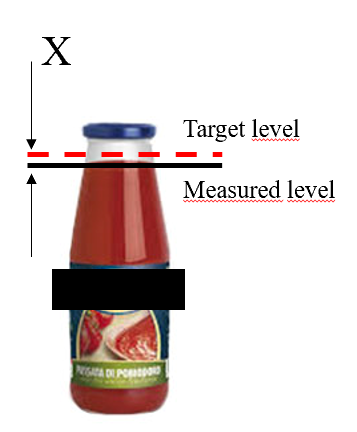

The data for 300 consecutive measurements are reported in the provided file `tomato_sauce.csv`.
Since the measured data are auto-correlated, check if:
- Data batching is suitable to get rid of the data auto-correlation
- Data gapping is suitable to get rid of the data auto-correlation
- Comment the results

In [ ]:
# Import the necessary libraries
import qdatoolkit as qda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Import the dataset
data = pd.read_csv('../../Dataset/tomato_sauce.csv')

data.head()

In [ ]:
#Time series plot
plt.figure(figsize=(15, 5))
plt.plot(data, 'o-')
plt.title('Time series plot')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()


In [ ]:
# Perform the runs test, plot the acf and plot the pacf with qda-toolkit
_ = qda.Assumptions(data['mm']).independence()  

In [ ]:
# Perform Bartlett's test at lag 1
_ = qda.Assumptions(data['mm']).independence(plotit = False, ac_test='bartlett', lag=1)

In [ ]:
# Perform LBQ test for autocorrelation at lag 4
_ = qda.Assumptions(data['mm']).independence(plotit = False, ac_test='lbq', lag=4)

The data are auto-correlated, check if:
1. Data gapping is suitable to get rid of the data autocorrelation. 
2. Data batching is suitable to get rid of the data autocorrelation. 

> Let's try data gapping first. 

In [ ]:
#Gapping 
gap_size= 6 # this is just an example, you can try different gapping intervals
gap_num= int(len(data)/gap_size)

gap_data= np.zeros((gap_num))
for i in range (gap_num):
    gap_data[i]=data['mm'][i*6]

> Alternatively, use the built-in array manipulation functionalities:

In [ ]:
# Take one data point every 6
gap_data = data['mm'][::gap_size]

> Let's analyze data after gapping

In [ ]:
#Time series plot and runs test
plt.plot(gap_data, 'o-')
plt.title('Time series plot')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()


In [ ]:
# Runs test, ACF and PACF for gapped data
_ = qda.Assumptions(gap_data).independence()
    

In [ ]:
# Perform Bartlett's test at lag 1 for gapped data
_ = qda.Assumptions(gap_data).independence(plotit = False, ac_test='bartlett', lag=1)


> Let's try with batching. Create 50 subgroups of size 6. 

In [ ]:
# Batching
batch_size = 6
batch_num = int(len(data)/batch_size)

j=0
batch_data = np.zeros((batch_num))
for i in range (batch_num):
    batch_data[i]=np.sum(data['mm'][j:j+batch_size])/batch_size
    j=j+batch_size

In [ ]:
# Alternative method
# Create a new column in the dataframe with the corresponding batch number
data['Batch'] = np.repeat(np.arange(1, batch_num+1), batch_size)

In [ ]:
# Store the batch means in a new dataframe
batch_data = data.groupby('Batch').mean()

Let's analyze data after batching

In [ ]:
#Time series plot
plt.plot(batch_data, 'o-')
plt.title('Time series plot')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()


> Check if the data are random.

In [ ]:
# Runs test, ACF and PACF for gapped data
_ = qda.Assumptions(batch_data).independence()

> Now check for autocorrelation.

In [ ]:
# Perform Bartlett's test at lag 1 for gapped data
_ = qda.Assumptions(batch_data).independence(plotit = False, ac_test='bartlett', lag=1)

From the autocorrelation tests at lag 1, we can see that batching is not suitable to get rid of the data autocorrelation completely. 